[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EelcoHoogendoorn/numga/blob/rewrite/rewrite/examples/geometry/multiview/multiview_reconstruction.ipynb) [![Open in GitHub Codespaces](https://github.com/codespaces/badge.svg)](https://codespaces.new/EelcoHoogendoorn/numga?ref=rewrite)

# Multi-View Scene Reconstruction & Camera Alignment in PGA2D

When multiple cameras observe a scene, our goal is to jointly reconstruct scene points and align camera poses.

Rather than shuffling coordinate matrices and ray-intersection heuristics, this notebook uses **extensors** (linear maps between blade subspaces):
sensor pixels lift into perspective sight cones, directional constraints from multiple cameras fuse by simple addition into confidence ellipses (Gaussian splats), and point centers are extracted in closed form via polar duality.


In [1]:
# Setup environment: clone repository and install dependencies if running in Colab
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    import os, shutil, subprocess
    os.chdir("/content")  # Always reset to /content
    repo_dir = Path("/content/numga_repo")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "-b", "rewrite", "https://github.com/EelcoHoogendoorn/numga.git", str(repo_dir)], check=True)
    else:
        subprocess.run(["git", "-C", str(repo_dir), "pull", "origin", "rewrite"], check=False)
    rewrite_dir = repo_dir / "rewrite"
    src_dir = rewrite_dir / "src"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "imageio"], check=True)
    for p in [str(src_dir), str(rewrite_dir)]:
        if p not in sys.path:
            sys.path.insert(0, p)

# Ensure rewrite root is in sys.path when running locally:
for cand in [Path.cwd(), *Path.cwd().parents]:
    if (cand / "examples" / "geometry" / "multiview").is_dir():
        if str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
        break
    if (cand / "rewrite" / "examples" / "geometry" / "multiview").is_dir():
        p = str(cand / "rewrite")
        if p not in sys.path:
            sys.path.insert(0, p)
        break

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

from examples.geometry.multiview import render
from examples.geometry.multiview.types import (
    Camera,      # Projective transformation extensor: Point <- Point
    Motor,       # Even-grade multivector: rigid planar motions in SE(2)
    Plane,       # Grade-1 multivector: lines in 2D / planes in 3D (a*x + b*y + c*w = 0)
    Point,       # Grade-2 multivector: 2D points [x, y, w]
    PointMap,    # Projective camera mapping extensor: Point <- Point
    Quadric,     # Bilinear form extensor: Plane <- Point (or Point <- Plane)
    Scalar,      # Grade-0 multivector: scalar values
    Twist,       # Lie algebra se(2) generator for infinitesimal twists
    TwistMap,    # Lie algebra extensor: Twist <- Twist
    coordinates, # Readout helper: converts normalized Point multivectors to NumPy arrays
    mv,          # Basis multivector generator (mv.x, mv.y, mv.w, mv.xy, mv.xw, mv.yw)
    point,       # Algebraic constructor: converts NumPy arrays to typed Point multivectors
    stack,       # Extensor stacking utility across axes
    w,           # The ideal line/plane at infinity: mv.w
)

## 1. Setup Scene and 3-Camera Rig

We place 6 ground truth scene points in front of a convergent 3-camera rig (left, center, and right viewpoints).

In standard GA, projecting a point joins it with the pinhole origin `c0` and meets it with the sensor line `screen`: `(c0 & p) ^ screen`. In numga, leaving the operand unbound as the type `Point` compiles directly into an **Extensor**—a compiled linear map between blade subspaces (`Point <- Point`).


Projective camera kernel (3x3):
 [[-1  0  0]
 [ 0 -1  0]
 [ 0 -1  0]]


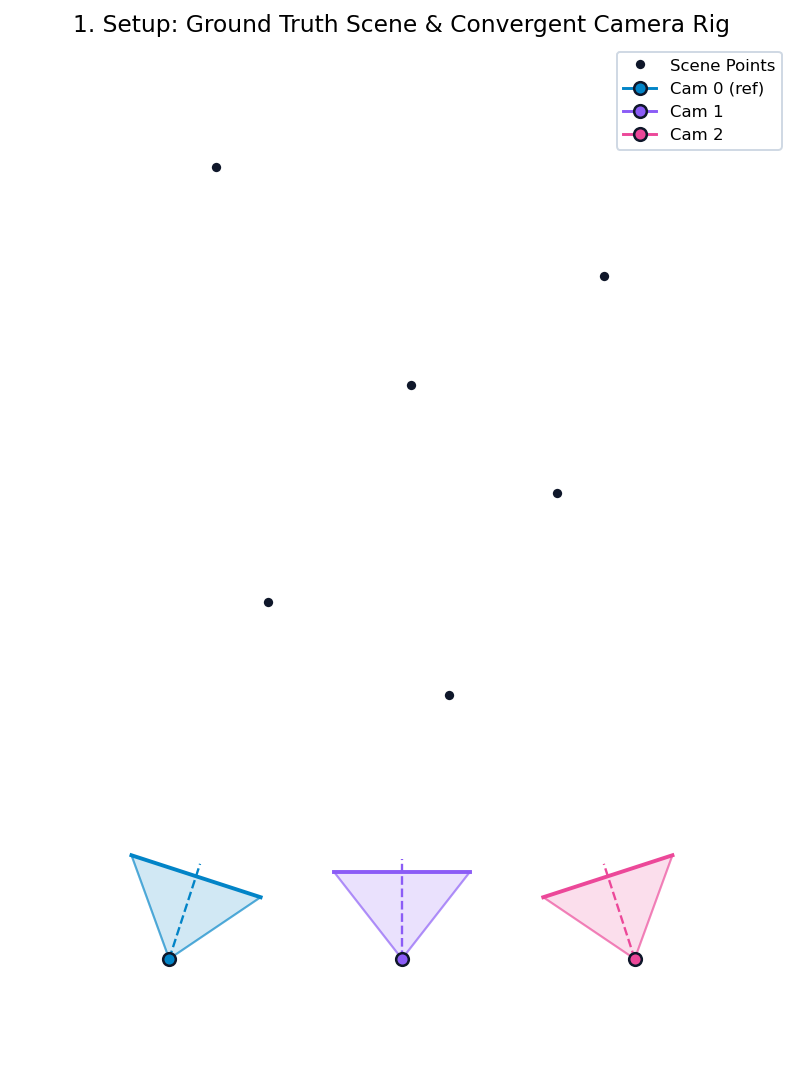

In [3]:
# 1. Define 6 ground truth scene points in front of the cameras:
coords = np.array([
    [ 0.15, 0.85],
    [-0.43, 1.15],
    [ 0.50, 1.50],
    [ 0.03, 1.85],
    [ 0.65, 2.20],
    [-0.60, 2.55],
])
true_points = point(coords)                         # [n_points] Point

# 2. Construct 3 convergent camera poses (left, center, right):
xs = np.array([-0.75, 0.0, 0.75])
thetas = np.radians([18.0, 0.0, -18.0])
true_poses = ((mv.xw * xs) * 0.5).exp() * ((mv.xy * thetas) * 0.5).exp()  # [n_cams] Motor

# 3. Construct projective camera model (Point <- Point):
c0 = point([0.0, 0.0])                              # Point (pinhole origin)
screen = mv.y - mv.w                                # Line (sensor line y = 1)
projection = (c0 & Point) ^ screen                  # PointMap: Point <- Point

print("Projective camera kernel (3x3):\n", projection.kernel.astype(int))

# Plot 1: Setup - Ground truth scene points and convergent camera rig
fig = render.draw_top_down_figure(
    poses=true_poses,
    points=true_points,
    cam_colors=["#0284c7", "#8b5cf6", "#ec4899"],
)
plt.title("1. Setup: Ground Truth Scene & Convergent Camera Rig")
plt.show()

## 2. Sensor Pixel Measurements & Perspective Sight Cones

Projecting scene points produces 1D transverse pixel measurements on the sensor lines (rank-1 precision dyads).
Pulling these dyads back through the camera model lifts them into 2D perspective sight cones (`Plane <- Point`), which we transform to world coordinates with camera poses.


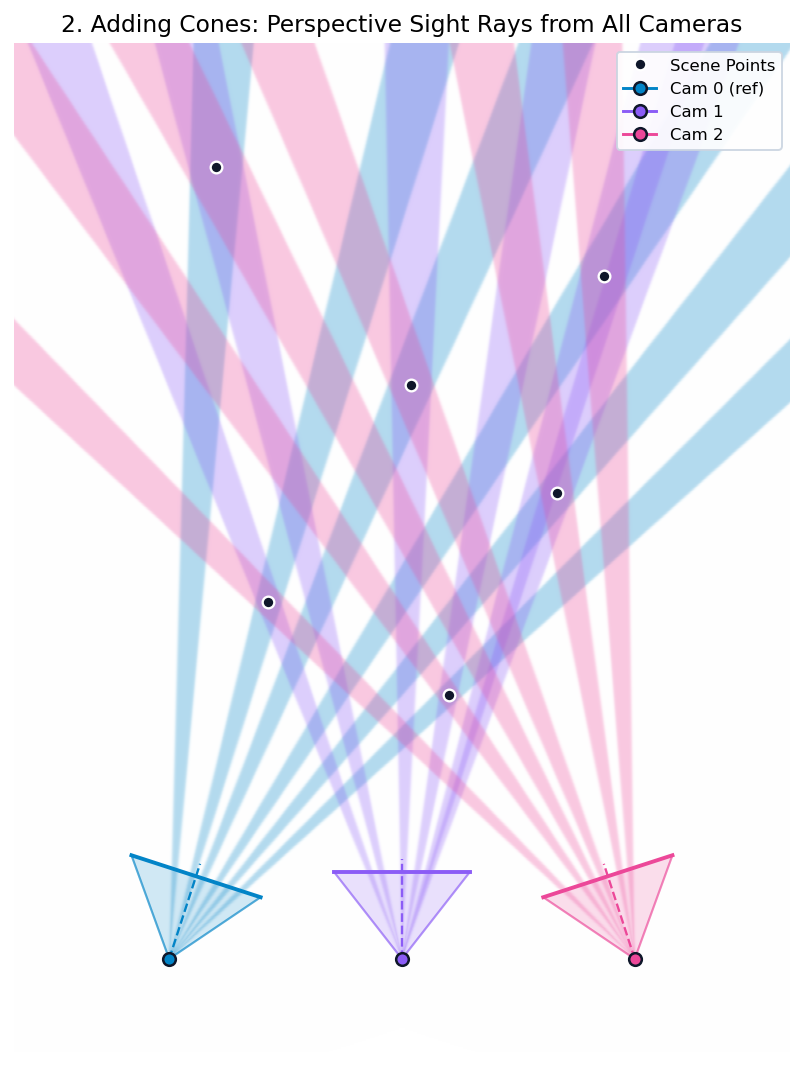

In [4]:
# 1. Project scene points into cameras: compute perspective projection and homogeneous pixel positions:
local_points = true_poses << true_points[:, None]   # [n_points, n_cams] Point
projs = projection(local_points)                    # [n_points, n_cams] Point
pixels = projs / (mv.w & projs)                     # [n_points, n_cams] Point (homogeneous coordinates)

# 2. Measure pixel precision on sensor plane (transverse precision dyads):
# At each measured pixel, transverse uncertainty is measured quadratically as (normal & Point)^2:
normal = mv.x - mv.w * (mv.x & pixels)              # [n_points, n_cams] Plane (transverse normal lines)
sensor_discs = normal * (normal & Point)            # [n_points, n_cams] Plane <- Point (sensor precision dyads)

# 3. Lift sensor pixels into sight cones (inverse-perspective pullback):
# Pulling sensor discs back through camera projection lifts 1D pixels into 2D perspective quadric cones:
pullback = projection.transpose()(Plane.dual()).dual_inverse()  # Plane <- Plane (adjoint C^T)
cones = pullback(sensor_discs(projection))          # [n_points, n_cams] Quadric (Plane <- Point)

# 4. Move sight cones into world space (double-sided extensor transport):
# `true_poses >> cones` transforms output planes from local to world.
# To make it a full world-to-world map (Plane_world <- Point_world), we also inverse-transform
# the input domain with `true_poses << Point`:
world_cones = true_poses >> cones(true_poses << Point)  # [n_points, n_cams] Quadric in world frame

# Plot 2: Adding Cones - Perspective sight rays fanning out through scene points
fig = render.draw_top_down_figure(
    poses=true_poses,
    cones=world_cones,
    points=true_points,
    cam_colors=["#0284c7", "#8b5cf6", "#ec4899"],
)
plt.title("2. Adding Cones: Perspective Sight Rays from All Cameras")
plt.show()


## 3. Closed-Form Point Reconstruction & Pre-Optimization Geometry

Summing sight cones across all cameras fuses directional constraints into localized confidence ellipses (Gaussian splats). By polar duality, solving `splats.solve(w)` extracts the Euclidean center of each quadric in closed form without ray heuristics.

Below, we perturb Camera 2 to introduce pose error and reconstruct the initial splats.


Pre-optimization point RMSE (Cam 2 perturbed): 0.079667 m (7.97 cm)


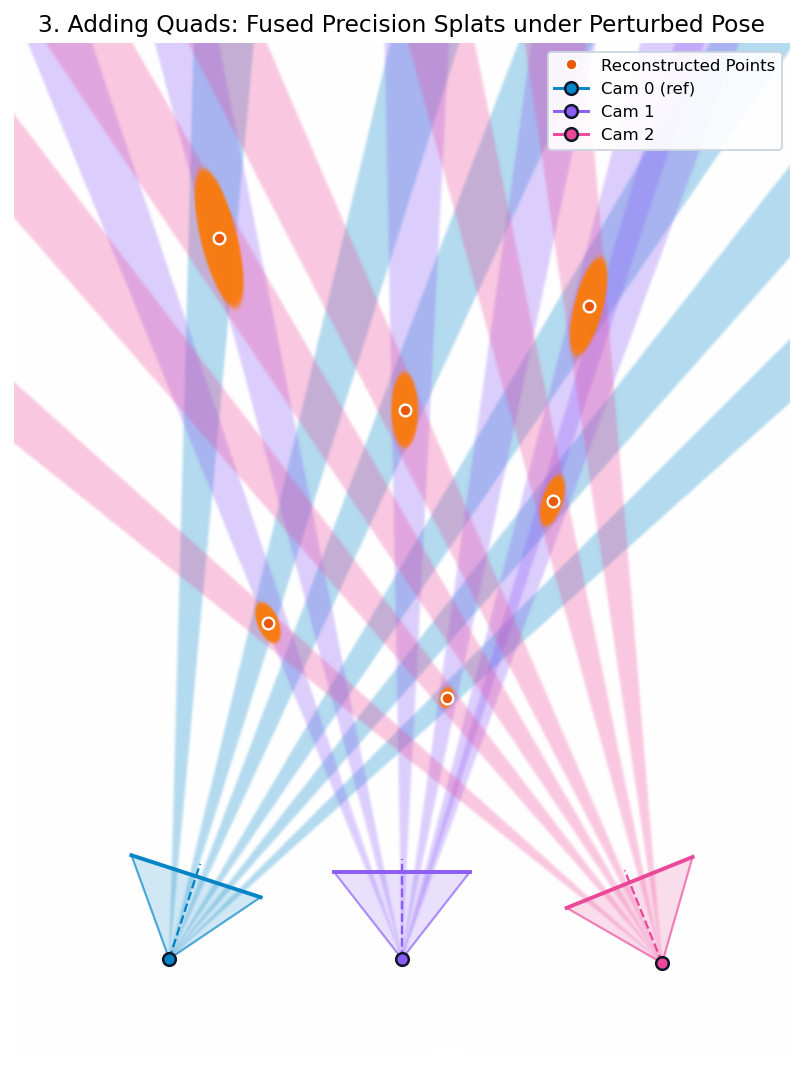

In [5]:
def triangulate_cones(poses: Motor, cones: Quadric) -> tuple[Point, Quadric]:
    """Triangulate scene points as poles of infinity from fused sight cone quadrics."""
    # 1. Move sight cones to world space (double-sided extensor transport):
    #    pulls back world points to local camera frames and pushes output planes forward into world space:
    world_cones = poses >> cones(poses << Point)    # [n_points, n_cams] Quadric: Plane_world <- Point_world

    # 2. Fuse sight cones across all cameras (additive multi-view fusion):
    #    summing quadratic directional constraints across viewpoints produces localized confidence ellipsoids (splats):
    splats = world_cones.sum(axis=-1)               # [n_points] Quadric: Plane_world <- Point_world

    # 3. Extract point centers in closed form (projective polar duality):
    #    the center of each quadric is the pole of the ideal line at infinity `w` (regularized for homogeneous gauge):
    points = (splats + mv.w * (mv.w & Point)).solve(mv.w).normalized()  # [n_points] Point

    return points, splats


# Perturb Camera 2 (right camera): +8 cm x, -4 cm y, -4 deg yaw:
pert2 = ((mv.xw * 0.08 - mv.yw * 0.04) * 0.5).exp() * ((-mv.xy * np.radians(4.0)) * 0.5).exp()
initial_poses = stack([true_poses[0], true_poses[1], true_poses[2] * pert2])  # [n_cams] Motor

# Initial closed-form triangulation:
init_points, init_splats = triangulate_cones(initial_poses, cones)
init_rmse = np.sqrt(np.mean((coordinates(init_points) - coords) ** 2))
print(f"Pre-optimization point RMSE (Cam 2 perturbed): {init_rmse:.6f} m ({init_rmse * 100:.2f} cm)")

# Plot 3: Adding Quads - Fused precision splats under perturbed pose
# Move sight cones to world space under perturbed camera poses:
init_world_cones = initial_poses >> cones(initial_poses << Point)
fig = render.draw_top_down_figure(
    poses=initial_poses,
    cones=init_world_cones,
    splats=init_splats,
    points=init_points,
    cam_colors=["#0284c7", "#8b5cf6", "#ec4899"],
)
plt.title("3. Adding Quads: Fused Precision Splats under Perturbed Pose")
plt.show()


## 4. Alternating Camera Alignment

We align camera poses by alternating between closed-form point reconstruction and camera pose updates:
1. **Reconstruct Points**: Closed-form pole-of-infinity solve from fused sight cones: `triangulate_cones(poses, cones)`.
2. **Measure Alignment Error**: Map current points into local camera frames and evaluate sight-cone residuals: `res = cones(local_points)`.
3. **Pose Jacobians**: Variations under infinitesimal rotation and translation steps (Lie algebra twists) yield `j = -cones(Twist.commutator(local_points))`.
4. **Solve & Update**: Form the Gauss-Newton curvature `h = (j.T @ j).sum()` and gradient `rhs = -(j.T @ res).sum()`, solve for the twist step, and update camera poses with `poses = poses * (step * 0.5).exp()`.


Iter  | Point RMSE (m)   | Step Norm     
------------------------------------------
Iteration  1 | Point RMSE: 0.079667 m | Step norm: 5.5133e-02
Iteration  2 | Point RMSE: 0.079053 m | Step norm: 2.7793e-02
Iteration  3 | Point RMSE: 0.078836 m | Step norm: 1.4031e-02
Iteration  4 | Point RMSE: 0.078740 m | Step norm: 7.1011e-03
Iteration  5 | Point RMSE: 0.078686 m | Step norm: 3.6225e-03
Iteration  6 | Point RMSE: 0.078648 m | Step norm: 1.9011e-03
Iteration  7 | Point RMSE: 0.078617 m | Step norm: 1.0895e-03
Iteration  8 | Point RMSE: 0.078589 m | Step norm: 7.5157e-04

Alternating Loop Final Point RMSE: 0.078562 m (7.86 cm)


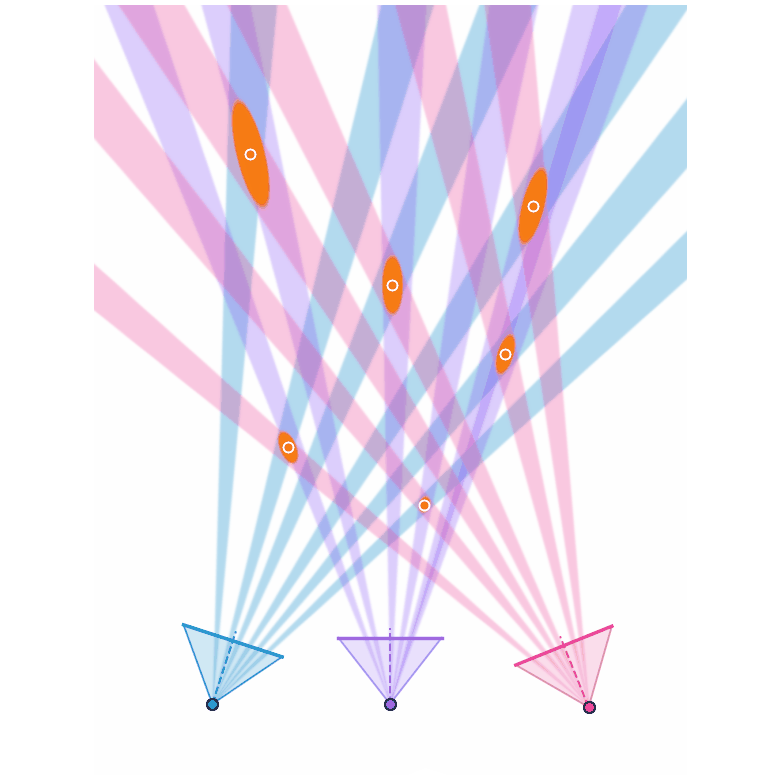

In [6]:
# Alternating Gauss-Newton optimization:
poses = initial_poses                                        # [n_cams] Motor
damping = 0.5
iterations = 8

history = []

print(f"{'Iter':<5} | {'Point RMSE (m)':<16} | {'Step Norm':<14}")
print("-" * 42)

for it in range(iterations):
    # 1. Reconstruct scene points: freeze camera poses and extract points as poles of infinity (polar duality):
    points, splats = triangulate_cones(poses, cones)
    history.append((poses, points, splats))

    # 2. View from camera: transform world points into each camera's local frame (motor pullback):
    local_points = poses << points[:, None]                 # [n_points, n_cams] Point (local coordinates)

    # 3. Measure alignment error: evaluate sight cones on points; on-axis points have zero error (polar residual lines):
    res = cones(local_points)                               # [n_points, n_cams] Line (polar error lines)

    # 4. Compute camera sensitivity: rate of change of error lines under rotation/translation steps (pose Jacobian via bivector commutators):
    j = -cones(Twist.commutator(local_points))              # [n_points, n_cams] Extensor: Line <- Twist

    # 5. Accumulate camera stiffness: sum curvature across points into total rotational and translational stiffness (Gauss-Newton extensor j.T @ j):
    h = (j.transpose()(j)).sum(axis=0)                      # [n_cams] Extensor: Twist <- Twist

    # 6. Accumulate corrective force: back-project line errors to form the camera update gradient (rhs = -j.T @ res):
    rhs = -(j.transpose()(res)).sum(axis=0)                 # [n_cams] Twist (Lie algebra update force)

    # 7. Solve for camera update step: solve stiffness against force (h(step) = rhs on the Lie algebra of twists):
    step = h.solve(rhs)                                     # [n_cams] Twist (infinitesimal pose step)

    # 8. Update camera poses: apply rigid body step to each camera (rotor exponential on motor manifold):
    poses = poses * (step * (0.5 * damping)).exp()          # [n_cams] Motor (updated camera poses)

    current_rmse = np.sqrt(np.mean((coordinates(points) - coords) ** 2))
    print(f"Iteration {it + 1:2d} | Point RMSE: {current_rmse:.6f} m | Step norm: {np.linalg.norm(step.kernel):.4e}")

opt_poses_alt = poses                                       # [n_cams] Motor
opt_points_alt, opt_splats_alt = triangulate_cones(opt_poses_alt, cones)
history.append((opt_poses_alt, opt_points_alt, opt_splats_alt))

alt_rmse = np.sqrt(np.mean((coordinates(opt_points_alt) - coords) ** 2))
print(f"\nAlternating Loop Final Point RMSE: {alt_rmse:.6f} m ({alt_rmse * 100:.2f} cm)")

# Convergence animation of alternating camera alignment:
gif_path = render.animate_top_down_convergence(
    history=history,
    local_cones=cones,
    cam_colors=["#0284c7", "#8b5cf6", "#ec4899"],
    fps=3,
)
display(Image(filename=str(gif_path)))

## 5. Camera Pose Uncertainty & Covariance Geometry

Inverting the accumulated Gauss-Newton curvature extensor (`h: Twist <- Twist`) directly yields the posterior pose covariance extensor for each camera (`pose_covariance: Twist <- Twist`). From this extensor, we extract 1-sigma positional uncertainty ellipses for camera centers and angular heading fans for orientations.


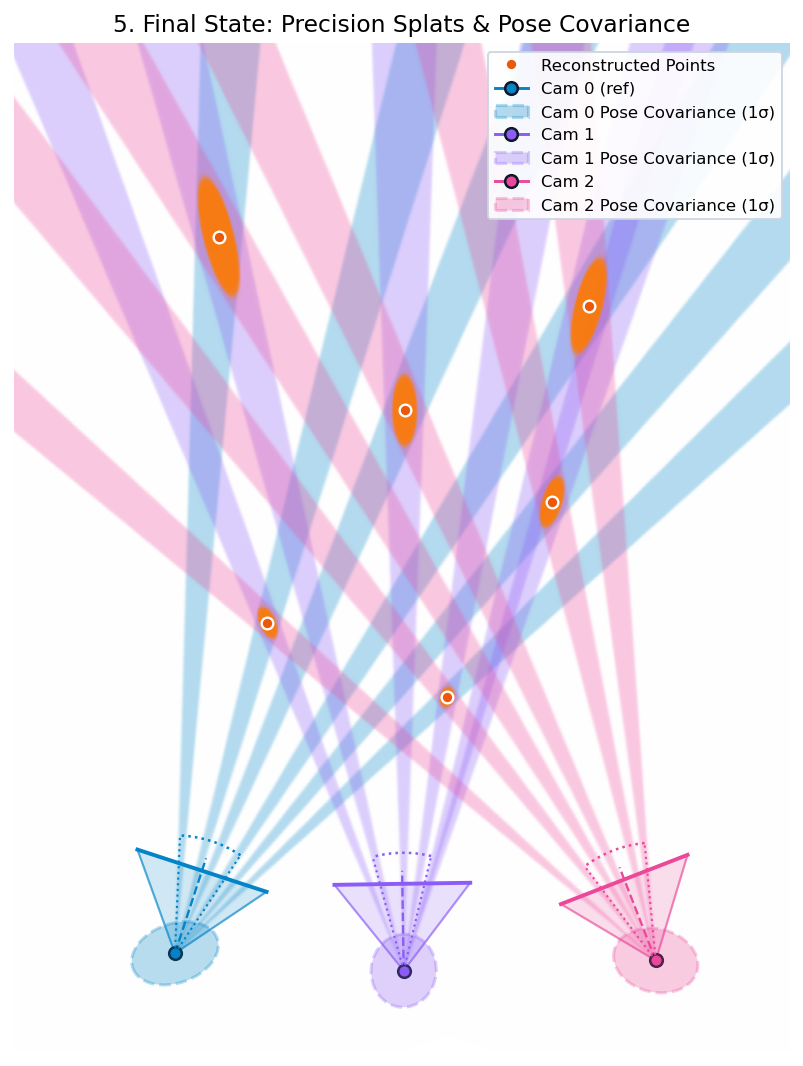


=== Reconstruction Accuracy Progression ===
1. Pre-optimization (perturbed Cam 2): 7.967 cm
2. Converged Landmark RMSE           : 7.856 cm
Camera 2 Positional 1-sigma uncertainty: [x: 143.557 cm, y: 158.834 cm]
Camera 2 Orientation 1-sigma uncertainty: 45.164 deg


In [7]:
# 1. Estimate camera pose uncertainty:
# Inverting the accumulated camera stiffness (h) yields the posterior pose covariance extensor (Twist <- Twist):
h_final = (j.transpose()(j)).sum(axis=0)                    # [n_cams] Extensor: Twist <- Twist (curvature)
pose_covariance = h_final.pinv(rcond=1e-4)                  # [n_cams] Extensor: Twist <- Twist (covariance)

# 2. Render final reconstructed state:
# Move sight cones to world space using the optimized camera poses (double-sided extensor transport):
opt_world_cones_final = opt_poses_alt >> cones(opt_poses_alt << Point)
fig = render.draw_top_down_figure(
    poses=opt_poses_alt,
    cones=opt_world_cones_final,
    splats=opt_splats_alt,
    points=opt_points_alt,
    pose_covariances=pose_covariance,
    cam_colors=["#0284c7", "#8b5cf6", "#ec4899"],
)
plt.title("5. Final State: Precision Splats & Pose Covariance")
plt.show()

print("\n=== Reconstruction Accuracy Progression ===")
print(f"1. Pre-optimization (perturbed Cam 2): {init_rmse * 100:.3f} cm")
print(f"2. Converged Landmark RMSE           : {alt_rmse * 100:.3f} cm")

# Camera 2 position and angular uncertainty readout from pose covariance extensor:
sigma_pos_cam2 = np.sqrt(np.diag(pose_covariance.kernel[2])[:2])
sigma_yaw_cam2 = np.degrees(np.sqrt(pose_covariance.kernel[2, 2, 2]))
print(f"Camera 2 Positional 1-sigma uncertainty: [x: {sigma_pos_cam2[0]*100:.3f} cm, y: {sigma_pos_cam2[1]*100:.3f} cm]")
print(f"Camera 2 Orientation 1-sigma uncertainty: {sigma_yaw_cam2:.3f} deg")


## 6. Summary & Conceptual Synthesis

Having walked through the working pipeline, we can step back and examine how **extensors** structure the multi-view geometry:

* **Lifting Pixels into Sight Cones (Inverse-Perspective Back-Projection)**:
  1D transverse pixel detections on the sensor line pull back through the camera projection extensor into 2D perspective quadric cones (`cones = pullback(sensor_discs)`). This lifts rank-1 sensor precision into full directional constraints whose uncertainty naturally widens with depth.

* **Moving Extensors Between Frames (Double-Sided Motor Transport)**:
  Transforming a multivector takes one sandwich: `pose >> point`. But a quadric extensor is a map between blade subspaces (`Plane <- Point`). Transforming the extensor into world space transforms both its domain and codomain: `pose >> cones` transforms output planes from local to world, while `cones(pose << Point)` inverse-transforms input points from world to local.

* **Combining Camera Views by Addition (Additive Multi-View Fusion)**:
  Because quadrics represent quadratic costs, directional constraints from convergent viewpoints combine by direct addition (`splats = world_cones.sum(axis=-1)`), fusing multiple camera cones into localized Gaussian confidence ellipsoids (splats).

* **Finding Point Centers in Closed Form (Projective Polar Duality)**:
  By projective polar duality, the Euclidean center of a quadric is the pole of the ideal line at infinity `w`. Solving `splats.solve(w)` extracts the reconstructed point position in closed form without ray-intersection heuristics.

* **Aligning Cameras via Small Steps (Lie Algebra Bivector Commutators)**:
  Camera pose variations under infinitesimal rotation and translation steps are evaluated using Lie algebra bivector commutators (`Twist.commutator(local_points)`). The alternating loop refines camera poses and scene points in just 6 lines of GA code.

* **Mapping Camera Uncertainty (Posterior Pose Covariance Extensors)**:
  Inverting the accumulated Gauss-Newton curvature extensor directly yields the posterior pose covariance extensor (`Twist <- Twist`) for each camera, from which 1-sigma positional uncertainty ellipses and angular heading fans are extracted.
